[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/calculus/05_indefinite_and_definite_integrals/first_principles.ipynb)

# Module 05 — Indefinite and Definite Integrals

## 1. Why This Module Exists

Differential calculus answers a **local** question: given a trajectory $F$, what is its instantaneous rate $f = F'$? This module answers the **global** inverse question: given the rates $f$ across $[a, b]$, how much total change accumulated?

Two different objects both get called "the integral", and conflating them is the single most common error in the subject.

- The **indefinite integral** $\int f(x)\,dx$ is an *algebraic* object: the set of functions whose derivative is $f$. It is defined by inverting differentiation, and it exists only when such a function exists.
- The **definite integral** $\int_a^b f(x)\,dx$ is a *measure-theoretic* object: a limit of finite sums of rectangle areas. Its definition never mentions derivatives at all, and it exists for many functions that have no elementary antiderivative, such as $e^{-x^2}$.

There is no a priori reason these two constructions should be related. The **Fundamental Theorem of Calculus** is the statement that, under continuity, they are two views of one thing — and it is what this module is named after and what Section 5 proves in full.

The payoff is everywhere downstream. A probability density integrates to a probability; an expectation $\mathbb{E}[X] = \int x\,p(x)\,dx$ is an accumulation; a variable force does work $W = \int F\,dx$; a neural ODE maps $z(t_0)$ to $z(t_1)$ by integrating a learned velocity field; and every one of these is computed in practice by quadrature, whose error bounds come straight from the same rectangle-and-remainder analysis.

## 2. Intuition

Suppose a force $F(x)$ pushes a particle from $x = a$ to $x = b$. If $F$ were constant, work would be $F \cdot (b - a)$: one multiplication. Because $F$ varies, no single multiplication is right.

The repair is to *pretend* $F$ is constant on pieces small enough that the pretence costs little:

1. Cut $[a, b]$ into $n$ subintervals of widths $\Delta x_i$.
2. On each piece pick a sample point $\xi_i$ and pretend the force is $F(\xi_i)$ throughout.
3. Add up the pieces: $\sum_{i=1}^n F(\xi_i)\,\Delta x_i$.
4. Refine until the widest piece shrinks to zero.

Two honest bookkeepings bracket the truth. Replace $F$ on each piece by its **infimum** and you always undercount; replace it by its **supremum** and you always overcount. These are the lower and upper **Darboux sums** $L(f, P)$ and $U(f, P)$. The number we want is squeezed between them, and it is well defined exactly when the squeeze closes: $U - L \to 0$.

That single criterion is the whole theory. Continuity closes the gap because a continuous function cannot vary much on a short interval. Monotonicity closes it because the oscillations telescope. The Dirichlet function does not close it, because on every subinterval, however short, its infimum is $0$ and its supremum is $1$.

The figure below draws the squeeze for $f(x) = x^2$ on $[0, 1]$: the shaded lower rectangles sit under the curve, the outlined upper rectangles sit over it, and the true area $1/3$ is trapped between the two totals.

The preamble below fixes plotting defaults and the random generator, then defines the lower and upper Darboux sums for a uniform partition. For a **monotone increasing** $f$ the infimum and supremum on each subinterval are the left and right endpoint values, which is what `darboux_sums` exploits; `oscillation_sums` is the general version that samples the subinterval to estimate $m_i$ and $M_i$.

n=8   L=0.273438   U=0.398438   U-L=0.125000   true=1/3=0.333333


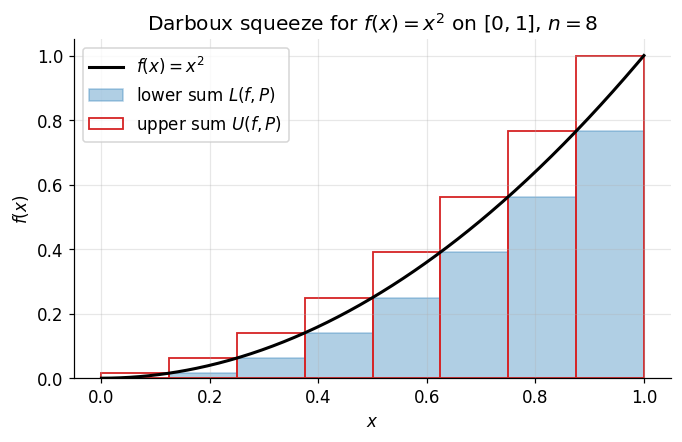

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)


def darboux_sums(f, a, b, n):
    """Lower and upper Darboux sums on a uniform partition, for monotone increasing f."""
    edges = np.linspace(a, b, n + 1)
    dx = (b - a) / n
    return float(np.sum(f(edges[:-1])) * dx), float(np.sum(f(edges[1:])) * dx)


def oscillation_sums(f, a, b, n, samples=400):
    """Lower and upper Darboux sums for a general f, by dense sampling of each subinterval."""
    edges = np.linspace(a, b, n + 1)
    dx = (b - a) / n
    lo = hi = 0.0
    for left, right in zip(edges[:-1], edges[1:]):
        vals = f(np.linspace(left, right, samples))
        lo += float(vals.min()) * dx
        hi += float(vals.max()) * dx
    return lo, hi


f_sq = lambda x: x**2
L8, U8 = darboux_sums(f_sq, 0.0, 1.0, 8)
print(f"n=8   L={L8:.6f}   U={U8:.6f}   U-L={U8 - L8:.6f}   true=1/3={1/3:.6f}")

fig, ax = plt.subplots()
edges = np.linspace(0.0, 1.0, 9)
dx = edges[1] - edges[0]
ax.bar(edges[:-1], f_sq(edges[:-1]), width=dx, align="edge",
       color="tab:blue", alpha=0.35, edgecolor="tab:blue", label=r"lower sum $L(f,P)$")
ax.bar(edges[:-1], f_sq(edges[1:]), width=dx, align="edge",
       facecolor="none", edgecolor="tab:red", linewidth=1.2, label=r"upper sum $U(f,P)$")
xs = np.linspace(0.0, 1.0, 400)
ax.plot(xs, f_sq(xs), "k-", linewidth=2, label=r"$f(x)=x^2$")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title(r"Darboux squeeze for $f(x)=x^2$ on $[0,1]$, $n=8$")
ax.legend(loc="upper left")
plt.show()

The lower total $0.2734$ undercounts and the upper total $0.3984$ overcounts the true value $1/3 \approx 0.3333$, with gap $U - L = 1/8$. Every additional cut narrows the band without ever letting the true value escape it — this is exactly the mechanism Theorem 4.4 turns into a proof.

## 3. Definitions

### Definition 3.1 (Antiderivative and indefinite integral)

Let $f : I \to \mathbb{R}$ on an interval $I \subseteq \mathbb{R}$. A function $F : I \to \mathbb{R}$ is an **antiderivative** (primitive) of $f$ on $I$ if $F$ is differentiable on $I$ and

$$
F'(x) = f(x) \quad \text{for every } x \in I .
$$

The set of all antiderivatives of $f$ on $I$ is the **indefinite integral**, written $\int f(x)\,dx$.

### Definition 3.2 (Partition and mesh)

Let $a \lt b$. A **partition** of $[a, b]$ is a finite set $P = \lbrace x_0, x_1, \dots, x_n \rbrace$ with

$$
a = x_0 \lt x_1 \lt \dots \lt x_n = b .
$$

The $i$-th subinterval is $[x_{i-1}, x_i]$ with width $\Delta x_i = x_i - x_{i-1}$, and the **mesh** of $P$ is $\lVert P \rVert = \max_{1 \le i \le n} \Delta x_i$. A partition $P^\ast$ **refines** $P$ if $P \subseteq P^\ast$.

### Definition 3.3 (Darboux sums)

For $f : [a, b] \to \mathbb{R}$ bounded and $P$ a partition, set

$$
m_i = \inf_{x \in [x_{i-1}, x_i]} f(x), \qquad M_i = \sup_{x \in [x_{i-1}, x_i]} f(x) .
$$

The **lower** and **upper Darboux sums** are

$$
L(f, P) = \sum_{i=1}^n m_i \, \Delta x_i, \qquad U(f, P) = \sum_{i=1}^n M_i \, \Delta x_i .
$$

Boundedness is what makes $m_i$ and $M_i$ finite; without it neither sum is defined. Since $m_i \le M_i$, always $L(f, P) \le U(f, P)$.

### Definition 3.4 (Lower and upper integrals; Darboux integrability)

$$
\underline{\int_a^b} f = \sup_P L(f, P), \qquad \overline{\int_a^b} f = \inf_P U(f, P) .
$$

$f$ is **Darboux integrable** on $[a, b]$ when these agree; the common value is written $\int_a^b f(x)\,dx$.

### Definition 3.5 (Tagged partition, Riemann sum, Riemann integrability)

A **tagged partition** $(P, \xi)$ adds tags $\xi_i \in [x_{i-1}, x_i]$. Its **Riemann sum** is

$$
S(f, P, \xi) = \sum_{i=1}^n f(\xi_i) \, \Delta x_i .
$$

$f$ is **Riemann integrable** with value $I$ if for every $\varepsilon \gt 0$ there is $\delta \gt 0$ such that every tagged partition with $\lVert P \rVert \lt \delta$ satisfies $\lvert S(f, P, \xi) - I \rvert \lt \varepsilon$.

### Definition 3.6 (Oscillation)

The **oscillation** of $f$ on a set $S$ is $\operatorname{osc}(f, S) = \sup_S f - \inf_S f$. With this notation $U(f, P) - L(f, P) = \sum_i \operatorname{osc}\!\big(f, [x_{i-1}, x_i]\big)\,\Delta x_i$, which is the quantity every integrability proof in Section 5 drives to zero.

### Definition 3.7 (Improper integral on an unbounded or singular domain)

If $f$ is Riemann integrable on $[a, t]$ for every $t \lt b$ but not on $[a, b]$ (because $b = \infty$ or $f$ is unbounded near $b$), then

$$
\int_a^b f(x)\,dx := \lim_{t \to b^-} \int_a^t f(x)\,dx
$$

whenever that limit exists in $\mathbb{R}$; otherwise the integral **diverges**. A singularity in the interior must be split at the singular point and each piece must converge separately.

## 4. Main Results

### Theorem 4.1 (Antiderivatives on an interval differ by a constant)

Let $I$ be an **interval** and let $F_1, F_2$ be antiderivatives of $f$ on $I$. Then $F_1 - F_2$ is constant on $I$.

*Why the hypothesis is needed.* $I$ must be an interval — that is, connected — because the proof moves between two points along a segment inside $I$; on $\mathbb{R} \setminus \lbrace 0 \rbrace$ the conclusion is false, and the constant may differ on each component.

### Theorem 4.2 (Darboux criterion)

A bounded $f : [a, b] \to \mathbb{R}$ is Darboux integrable **iff** for every $\varepsilon \gt 0$ there is a partition $P$ with

$$
U(f, P) - L(f, P) \lt \varepsilon .
$$

*Why the hypothesis is needed.* Boundedness makes $L$ and $U$ finite by Definition 3.3, so their difference is a real number that can be compared with $\varepsilon$.

### Theorem 4.3 (Continuity implies integrability)

If $f$ is **continuous** on the **closed bounded** interval $[a, b]$, then $f$ is Darboux integrable on $[a, b]$.

*Why each hypothesis is needed.* Continuity plus compactness gives **uniform** continuity, which is what lets one $\delta$ control the oscillation on *every* subinterval at once; on an open or unbounded interval, continuity alone gives no such uniform modulus, as $\sin(1/x)$ on $(0, 1]$ shows for boundedness of the modulus.

### Theorem 4.4 (Monotonicity implies integrability)

If $f$ is **monotone** on $[a, b]$, then $f$ is Darboux integrable on $[a, b]$, and for the uniform partition $P_n$,

$$
U(f, P_n) - L(f, P_n) = \frac{(b - a)\,\lvert f(b) - f(a) \rvert}{n} .
$$

*Why the hypothesis is needed.* Monotonicity forces $m_i$ and $M_i$ to be the two endpoint values, so the oscillations telescope. A monotone function may have countably many jumps, so continuity is genuinely not required.

### Theorem 4.5 (Lebesgue's criterion — cited, not proved here)

A bounded $f : [a, b] \to \mathbb{R}$ is Riemann integrable **iff** its set of discontinuities has Lebesgue measure zero.

Reference: Apostol, *Mathematical Analysis*, 2nd ed., §7.26, Theorem 7.48. This subsumes Theorems 4.3 and 4.4 and is proved from measure theory that this module does not build; the two special cases it generalises are proved in full by Proof 5.4 and Proof 5.5.

### Theorem 4.6 (Riemann equals Darboux — cited, not proved here)

A bounded $f$ on $[a, b]$ is Riemann integrable (Definition 3.5) iff it is Darboux integrable (Definition 3.4), and the two values coincide.

Reference: Rudin, *Principles of Mathematical Analysis*, 3rd ed., §6.1–6.7 (Theorem 6.6 and the remark following Definition 6.2); Apostol, *Mathematical Analysis*, 2nd ed., Theorem 7.19. Everything below uses the Darboux side, so nothing here depends on the unproved direction.

### Theorem 4.7 (Fundamental Theorem of Calculus, Part I)

Let $f$ be **continuous** on $[a, b]$ and define the accumulation function

$$
F(x) = \int_a^x f(t)\,dt .
$$

Then $F$ is differentiable on $[a, b]$ (one-sided at the endpoints) and

$$
\boxed{\ F'(x) = f(x) \quad \text{for every } x \in [a, b].\ }
$$

**Interpretation.** Accumulating $f$ and then differentiating returns $f$: integration is a genuine left inverse of differentiation on continuous functions. The consequence is existence — *every* continuous function on a closed interval has an antiderivative, namely its own accumulation function, even when no elementary formula for it exists.

*Why the hypothesis is needed.* Continuity at $x$ is what makes the average of $f$ over a shrinking interval around $x$ converge to $f(x)$. Merely integrable $f$ still gives a continuous $F$, but at a jump of $f$ the one-sided derivatives of $F$ differ, so $F'(x)$ need not exist.

### Theorem 4.8 (Fundamental Theorem of Calculus, Part II)

Let $f$ be **Riemann integrable** on $[a, b]$ and suppose $g$ is **continuous on $[a, b]$, differentiable on $(a, b)$**, with $g'(x) = f(x)$ for all $x \in (a, b)$. Then

$$
\boxed{\ \int_a^b f(x)\,dx = g(b) - g(a).\ }
$$

**Interpretation.** A definite integral — defined as a limit of sums that never mentions derivatives — is computed by two evaluations of any antiderivative. The consequence is that the entire catalogue of differentiation rules becomes a catalogue of integration rules, read backwards.

*Why each hypothesis is needed.* Integrability of $f$ is what makes the left side exist at all. Continuity of $g$ on the **closed** interval is what lets the telescoping sum reach the endpoints; $g(x) = -1/x$ fails it at $0$, which is exactly why $\int_{-1}^{1} x^{-2}\,dx = -2$ is nonsense (Section 7 runs the failure numerically).

### Theorem 4.9 (Leibniz integral rule)

Let $f$ and $\partial f / \partial x$ be **continuous** on $[a, b] \times [c, d]$, and let $u, v : [a, b] \to [c, d]$ be **continuously differentiable**. Then for $x \in (a, b)$,

$$
\boxed{\ \frac{d}{dx} \int_{u(x)}^{v(x)} f(x, t)\,dt = f\big(x, v(x)\big) v'(x) - f\big(x, u(x)\big) u'(x) + \int_{u(x)}^{v(x)} \frac{\partial f}{\partial x}(x, t)\,dt .\ }
$$

**Interpretation.** Three independent things change when $x$ moves: the top edge sweeps out area at rate $f(x, v)v'$, the bottom edge at rate $-f(x, u)u'$, and the integrand itself lifts or drops at rate $\partial f/\partial x$. The consequence is Feynman's technique — introduce a parameter, differentiate under the sign, solve the easier integral, then integrate back in the parameter.

*Why each hypothesis is needed.* Continuity of $\partial f/\partial x$ on the compact rectangle gives uniform continuity, which justifies exchanging the limit defining $\partial/\partial x$ with the integral; without it the exchange can fail. Continuous differentiability of $u, v$ is what the chain rule consumes.

### Theorem 4.10 (Change of variables)

If $g$ is **continuously differentiable** on $[a, b]$ and $f$ is **continuous** on an interval containing $g([a, b])$, then

$$
\int_a^b f\big(g(x)\big) g'(x)\,dx = \int_{g(a)}^{g(b)} f(u)\,du .
$$

*Why the hypotheses are needed.* Continuity of $f$ supplies an antiderivative by Theorem 4.7; continuity of $g'$ makes $f(g(\cdot))g'(\cdot)$ integrable. Monotonicity of $g$ is **not** required — the oriented limits $g(a), g(b)$ handle folding automatically.

### Theorem 4.11 (Integration by parts)

If $u, v$ are continuously differentiable on $[a, b]$, then

$$
\int_a^b u(x)v'(x)\,dx = \big[u(x)v(x)\big]_a^b - \int_a^b v(x)u'(x)\,dx .
$$

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

Let $g = F_1 - F_2$, so $g'(x) = f(x) - f(x) = 0$ on $I$. Fix $x_0 \in I$ and take any $x \in I$. Because $I$ is an interval, the closed segment between $x_0$ and $x$ lies in $I$, so $g$ is continuous there and differentiable inside, and the Mean Value Theorem gives $\xi$ strictly between them with

$$
g(x) - g(x_0) = g'(\xi)(x - x_0) = 0 .
$$

Hence $g \equiv g(x_0)$. On a disconnected domain the segment need not lie in the domain and the argument collapses: on $\mathbb{R} \setminus \lbrace 0 \rbrace$ the function equal to $0$ for $x \lt 0$ and $1$ for $x \gt 0$ has zero derivative and is not constant. $\blacksquare$

### Lemma 5.2 (Refinement)

If $P \subseteq P^\ast$ then $L(f, P) \le L(f, P^\ast) \le U(f, P^\ast) \le U(f, P)$.

**Proof.** It suffices to add one point $x^\ast \in (x_{k-1}, x_k)$; the general case follows by induction on $\lvert P^\ast \setminus P \rvert$. Write

$$
m_k = \inf_{[x_{k-1}, x_k]} f, \qquad m_k' = \inf_{[x_{k-1}, x^\ast]} f, \qquad m_k'' = \inf_{[x^\ast, x_k]} f .
$$

An infimum over a subset is at least the infimum over the whole set, so $m_k' \ge m_k$ and $m_k'' \ge m_k$, and therefore

$$
m_k'(x^\ast - x_{k-1}) + m_k''(x_k - x^\ast) \ge m_k(x^\ast - x_{k-1}) + m_k(x_k - x^\ast) = m_k \Delta x_k .
$$

All other terms are unchanged, so $L(f, P^\ast) \ge L(f, P)$; the supremum argument is symmetric and gives $U(f, P^\ast) \le U(f, P)$. The middle inequality is Definition 3.3. $\blacksquare$

**Corollary 5.3.** For *any* two partitions $P_1, P_2$, applying Lemma 5.2 to the common refinement $P_1 \cup P_2$ gives $L(f, P_1) \le U(f, P_2)$. Hence $\underline{\int_a^b} f \le \overline{\int_a^b} f$ always.

### Proof 5.4 (of Theorem 4.2, the Darboux criterion)

($\Leftarrow$) Suppose the $\varepsilon$-condition holds and pick such a $P$. Then

$$
0 \le \overline{\int_a^b} f - \underline{\int_a^b} f \le U(f, P) - L(f, P) \lt \varepsilon ,
$$

where the first inequality is Corollary 5.3 and the second holds because $\overline{\int} f \le U(f,P)$ and $\underline{\int} f \ge L(f,P)$ by definition of $\inf$ and $\sup$. As $\varepsilon \gt 0$ was arbitrary the two integrals are equal.

($\Rightarrow$) Suppose $f$ is integrable with value $I$ and let $\varepsilon \gt 0$. By definition of the infimum there is $P_1$ with $U(f, P_1) \lt I + \varepsilon/2$, and by definition of the supremum there is $P_2$ with $L(f, P_2) \gt I - \varepsilon/2$. Let $P = P_1 \cup P_2$. By Lemma 5.2,

$$
U(f, P) - L(f, P) \le U(f, P_1) - L(f, P_2) \lt \varepsilon . \qquad \blacksquare
$$

### Proof 5.5 (of Theorem 4.3)

$f$ is continuous on the compact set $[a, b]$, hence uniformly continuous (Heine–Cantor). Given $\varepsilon \gt 0$ choose $\delta \gt 0$ with

$$
\lvert x - y \rvert \lt \delta \implies \lvert f(x) - f(y) \rvert \lt \frac{\varepsilon}{2(b - a)} .
$$

Take any partition $P$ with $\lVert P \rVert \lt \delta$. On $[x_{i-1}, x_i]$ the Extreme Value Theorem supplies points $p_i, q_i$ with $f(p_i) = m_i$ and $f(q_i) = M_i$; they lie within $\delta$ of each other, so $M_i - m_i \lt \varepsilon / (2(b-a))$. Therefore

$$
U(f, P) - L(f, P) = \sum_{i=1}^n (M_i - m_i)\,\Delta x_i \le \frac{\varepsilon}{2(b-a)} \sum_{i=1}^n \Delta x_i = \frac{\varepsilon}{2} \lt \varepsilon ,
$$

and Theorem 4.2 finishes the proof. $\blacksquare$

### Proof 5.6 (of Theorem 4.4)

Take $f$ non-decreasing; the non-increasing case follows by replacing $f$ with $-f$. Then $f(a) \le f \le f(b)$, so $f$ is bounded. On the uniform partition $P_n$ with $\Delta x = (b-a)/n$, monotonicity gives $m_i = f(x_{i-1})$ and $M_i = f(x_i)$, so the sum telescopes:

$$
U(f, P_n) - L(f, P_n) = \Delta x \sum_{i=1}^n \big( f(x_i) - f(x_{i-1}) \big) = \frac{(b-a)\big(f(b) - f(a)\big)}{n} .
$$

Given $\varepsilon \gt 0$, any $n \gt (b-a)(f(b)-f(a))/\varepsilon$ makes this less than $\varepsilon$, so Theorem 4.2 applies. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, FTC Part I)

First, $F$ is well defined: $f$ is continuous on $[a, x]$ for each $x$, so it is integrable there by Theorem 4.3.

Fix $x \in [a, b]$ and let $h \ne 0$ be small enough that $x + h \in [a, b]$. Additivity of the integral over adjacent intervals gives

$$
F(x + h) - F(x) = \int_x^{x+h} f(t)\,dt .
$$

Let $I_h = [\min(x, x+h), \max(x, x+h)]$, an interval of length $\lvert h \rvert$. By the Extreme Value Theorem $f$ attains a minimum $m_h$ and a maximum $M_h$ on $I_h$, and monotonicity of the integral gives

$$
m_h \lvert h \rvert \le \int_{I_h} f(t)\,dt \le M_h \lvert h \rvert .
$$

**Case $h \gt 0$.** Here $\int_x^{x+h} f = \int_{I_h} f$ and dividing by $h \gt 0$ preserves the inequalities:

$$
m_h \le \frac{1}{h}\int_x^{x+h} f(t)\,dt \le M_h .
$$

**Case $h \lt 0$.** Here $\int_x^{x+h} f = -\int_{I_h} f$ by the orientation convention, and dividing by the negative number $h$ reverses the inequalities. The two sign reversals cancel and the same chain

$$
m_h \le \frac{1}{h}\int_x^{x+h} f(t)\,dt \le M_h
$$

holds again. So the bracket is valid for every admissible $h \ne 0$, which is what a two-sided derivative requires.

As $h \to 0$ the interval $I_h$ shrinks to $\lbrace x \rbrace$, and continuity of $f$ at $x$ forces $m_h \to f(x)$ and $M_h \to f(x)$. Indeed, given $\varepsilon \gt 0$ pick $\delta$ with $\lvert t - x \rvert \lt \delta \implies \lvert f(t) - f(x) \rvert \lt \varepsilon$; for $\lvert h \rvert \lt \delta$ every $t \in I_h$ satisfies this, so $m_h, M_h \in (f(x) - \varepsilon, f(x) + \varepsilon)$. The Squeeze Theorem now gives

$$
F'(x) = \lim_{h \to 0} \frac{F(x+h) - F(x)}{h} = f(x) .
$$

At $x = a$ only $h \gt 0$ is admissible and at $x = b$ only $h \lt 0$, giving the one-sided derivatives. $\blacksquare$

Nothing in this argument used an antiderivative of $f$, so it is not circular: it *constructs* one.

### Proof 5.8 (of Theorem 4.8, FTC Part II)

Let $P = \lbrace x_0, \dots, x_n \rbrace$ be any partition of $[a, b]$. Telescope:

$$
g(b) - g(a) = \sum_{i=1}^n \big( g(x_i) - g(x_{i-1}) \big) .
$$

On each $[x_{i-1}, x_i]$, $g$ is continuous (hypothesis on the closed interval) and differentiable on the interior, so the Mean Value Theorem gives $\xi_i \in (x_{i-1}, x_i)$ with

$$
g(x_i) - g(x_{i-1}) = g'(\xi_i)\,\Delta x_i = f(\xi_i)\,\Delta x_i .
$$

Hence $g(b) - g(a) = S(f, P, \xi)$ for this particular tag choice. Since $m_i \le f(\xi_i) \le M_i$,

$$
L(f, P) \le g(b) - g(a) \le U(f, P) \qquad \text{for every partition } P .
$$

Taking the supremum over $P$ on the left and the infimum on the right,

$$
\underline{\int_a^b} f \le g(b) - g(a) \le \overline{\int_a^b} f .
$$

Integrability of $f$ collapses the two outer quantities to the single number $\int_a^b f$, which therefore equals $g(b) - g(a)$. $\blacksquare$

Note the logical direction: Proof 5.8 assumes an antiderivative is *given* and does not use Theorem 4.7, while Proof 5.7 builds one and does not use Theorem 4.8. Neither proof assumes the other's conclusion.

### Proof 5.9 (of Theorem 4.10, change of variables)

$f$ is continuous, so by Theorem 4.7 it has an antiderivative $F$ on an interval containing $g([a,b])$. The chain rule gives $\frac{d}{dx} F(g(x)) = f(g(x))g'(x)$, and the right-hand side is continuous, hence integrable. Applying Theorem 4.8 twice,

$$
\int_a^b f(g(x))g'(x)\,dx = F(g(b)) - F(g(a)) = \int_{g(a)}^{g(b)} f(u)\,du . \qquad \blacksquare
$$

### Proof 5.10 (of Theorem 4.11, integration by parts)

$(uv)' = u'v + uv'$ is continuous on $[a, b]$, so Theorem 4.8 applied to $uv$ gives

$$
\big[u v\big]_a^b = \int_a^b \big( u'(x)v(x) + u(x)v'(x) \big)\,dx = \int_a^b u'v\,dx + \int_a^b uv'\,dx ,
$$

and rearranging is the claim. $\blacksquare$

### Proof 5.11 (of Theorem 4.9, Leibniz rule)

Define $G(x, p, q) = \int_p^q f(x, t)\,dt$ on $[a,b] \times [c,d] \times [c,d]$ and set $I(x) = G(x, u(x), v(x))$.

**Step 1 — the two boundary partials.** For fixed $x$ and $p$, the map $q \mapsto \int_p^q f(x, t)\,dt$ is the accumulation function of the continuous $t \mapsto f(x,t)$, so Theorem 4.7 gives $\partial G/\partial q = f(x, q)$. Reversing orientation, $\partial G/\partial p = -f(x, p)$.

**Step 2 — the integrand partial.** Fix $p, q$ and let $\Phi(x) = \int_p^q f(x,t)\,dt$. For $h \ne 0$, the Mean Value Theorem applied in the first argument gives, for each $t$, a point $\theta_t$ between $x$ and $x + h$ with

$$
\frac{f(x+h, t) - f(x, t)}{h} = \frac{\partial f}{\partial x}(\theta_t, t) .
$$

Because $\partial f/\partial x$ is continuous on the compact rectangle it is uniformly continuous there, so given $\varepsilon \gt 0$ there is $\delta \gt 0$ with $\lvert \partial f/\partial x(\theta_t, t) - \partial f/\partial x(x, t) \rvert \lt \varepsilon$ whenever $\lvert h \rvert \lt \delta$, uniformly in $t$. Hence

$$
\left\lvert \frac{\Phi(x+h) - \Phi(x)}{h} - \int_p^q \frac{\partial f}{\partial x}(x, t)\,dt \right\rvert \le \int_p^q \left\lvert \frac{\partial f}{\partial x}(\theta_t, t) - \frac{\partial f}{\partial x}(x, t) \right\rvert dt \le \varepsilon \lvert q - p \rvert ,
$$

which tends to $0$. So $\partial G/\partial x = \int_p^q \frac{\partial f}{\partial x}(x,t)\,dt$.

**Step 3 — assemble.** All three partials of $G$ are continuous, so $G$ is differentiable and the multivariable chain rule applies to $I(x) = G(x, u(x), v(x))$:

$$
I'(x) = \frac{\partial G}{\partial x} + \frac{\partial G}{\partial p}\,u'(x) + \frac{\partial G}{\partial q}\,v'(x) = \int_{u(x)}^{v(x)} \frac{\partial f}{\partial x}(x,t)\,dt - f(x, u(x))u'(x) + f(x, v(x))v'(x) . \qquad \blacksquare
$$

### Derivation 5.12 (Weierstrass half-angle substitution)

Set $t = \tan(x/2)$ for $x \in (-\pi, \pi)$, so $x = 2\arctan t$ and

$$
dx = \frac{2}{1 + t^2}\,dt .
$$

Since $\sec^2(x/2) = 1 + t^2$, i.e. $\cos^2(x/2) = 1/(1+t^2)$,

$$
\sin x = 2\sin\tfrac{x}{2}\cos\tfrac{x}{2} = 2\tan\tfrac{x}{2}\cos^2\tfrac{x}{2} = \frac{2t}{1 + t^2}, \qquad
\cos x = \cos^2\tfrac{x}{2} - \sin^2\tfrac{x}{2} = \cos^2\tfrac{x}{2}\big(1 - t^2\big) = \frac{1 - t^2}{1 + t^2} .
$$

Any $\int R(\sin x, \cos x)\,dx$ with $R$ rational therefore becomes a rational integral in $t$, which partial fractions always solves. The substitution is legitimate on any interval avoiding the odd multiples of $\pi$, where $\tan(x/2)$ blows up. $\blacksquare$

## 6. Worked Examples

### Example 6.1 (Theorem 4.4 and Theorem 4.2 on $f(x) = x^2$, $[0,1]$, $n = 4$)

$f(x) = x^2$ is increasing on $[0,1]$, so on the uniform partition $P_4 = \lbrace 0, \tfrac14, \tfrac12, \tfrac34, 1 \rbrace$ with $\Delta x = \tfrac14$ we have $m_i = f(x_{i-1})$, $M_i = f(x_i)$:

$$
L(f, P_4) = \tfrac14\left(0 + \tfrac{1}{16} + \tfrac{4}{16} + \tfrac{9}{16}\right) = \tfrac14 \cdot \tfrac{14}{16} = \frac{7}{32} = 0.21875 ,
$$

$$
U(f, P_4) = \tfrac14\left(\tfrac{1}{16} + \tfrac{4}{16} + \tfrac{9}{16} + \tfrac{16}{16}\right) = \tfrac14 \cdot \tfrac{30}{16} = \frac{15}{32} = 0.46875 .
$$

The gap is $U - L = \tfrac{8}{32} = \tfrac14 = \frac{(b-a)(f(b)-f(a))}{n} = \frac{1 \cdot 1}{4}$, matching Theorem 4.4 exactly, and $\tfrac{7}{32} \le \tfrac13 \le \tfrac{15}{32}$.

### Example 6.2 (Theorem 4.8 on $\int_0^1 x^2\,dx$ and $\int_1^2 \frac{dx}{x}$)

$g(x) = x^3/3$ is continuous on $[0,1]$, differentiable inside, and $g'(x) = x^2$, so

$$
\int_0^1 x^2\,dx = \frac{1^3}{3} - \frac{0^3}{3} = \frac13 .
$$

$g(x) = \ln x$ is continuous on $[1,2]$ with $g'(x) = 1/x$, so $\int_1^2 \frac{dx}{x} = \ln 2 - \ln 1 = \ln 2 \approx 0.693147$.

### Example 6.3 (Theorem 4.9 with both boundaries moving)

Take $f(x, t) = x t$, $u(x) = x$, $v(x) = x^2$, and $I(x) = \int_{x}^{x^2} x t\,dt$. Directly,

$$
I(x) = x \cdot \frac{t^2}{2}\Big|_{x}^{x^2} = \frac{x^5 - x^3}{2}, \qquad I'(x) = \frac{5x^4 - 3x^2}{2} .
$$

Through Theorem 4.9, with $v' = 2x$, $u' = 1$, $\partial f/\partial x = t$:

$$
I'(x) = \underbrace{x \cdot x^2}_{f(x,v)} \cdot 2x - \underbrace{x \cdot x}_{f(x,u)} \cdot 1 + \int_x^{x^2} t\,dt = 2x^4 - x^2 + \frac{x^4 - x^2}{2} = \frac{5x^4 - 3x^2}{2} .
$$

At $x = 2$ both give $(5 \cdot 16 - 3 \cdot 4)/2 = 34$.

### Example 6.4 (Derivation 5.12 and Theorem 4.10 on $\int_0^{\pi/2} \frac{dx}{1 + \sin x + \cos x}$)

With $t = \tan(x/2)$ the limits become $t = 0$ and $t = 1$, and the denominator collapses:

$$
1 + \frac{2t}{1+t^2} + \frac{1 - t^2}{1 + t^2} = \frac{(1 + t^2) + 2t + (1 - t^2)}{1 + t^2} = \frac{2 + 2t}{1 + t^2} .
$$

Multiplying by $dx = \frac{2\,dt}{1+t^2}$ cancels the $1 + t^2$ entirely:

$$
\int_0^{\pi/2} \frac{dx}{1 + \sin x + \cos x} = \int_0^1 \frac{2\,dt}{2 + 2t} = \big[\ln(1 + t)\big]_0^1 = \ln 2 .
$$

The cell below recomputes every number claimed in Examples 6.1–6.4 and asserts agreement with the hand values.

In [2]:
# --- Example 6.1: Darboux sums at n = 4, by hand versus by code ---
L4, U4 = darboux_sums(f_sq, 0.0, 1.0, 4)
print(f"Example 6.1: L(f,P4)={L4:.6f} (hand 7/32={7/32:.6f}), "
      f"U(f,P4)={U4:.6f} (hand 15/32={15/32:.6f}), gap={U4-L4:.6f} (hand 1/4)")
assert abs(L4 - 7 / 32) < 1e-12 and abs(U4 - 15 / 32) < 1e-12
assert abs((U4 - L4) - 0.25) < 1e-12 and L4 <= 1 / 3 <= U4

# --- Example 6.2: FTC II evaluations ---
quad_sq = 1.0**3 / 3 - 0.0**3 / 3
quad_log = np.log(2.0) - np.log(1.0)
print(f"Example 6.2: int_0^1 x^2 dx = {quad_sq:.6f} (1/3), "
      f"int_1^2 dx/x = {quad_log:.6f} (ln 2 = {np.log(2):.6f})")
assert abs(quad_sq - 1 / 3) < 1e-15 and abs(quad_log - np.log(2)) < 1e-15

# --- Example 6.3: Leibniz rule at x = 2, direct versus rule, versus finite difference ---
I_direct = lambda x: (x**5 - x**3) / 2
x0 = 2.0
by_rule = (5 * x0**4 - 3 * x0**2) / 2
by_fd = (I_direct(x0 + 1e-6) - I_direct(x0 - 1e-6)) / (2e-6)
print(f"Example 6.3: Leibniz rule gives {by_rule:.6f}, hand value 34, "
      f"central difference {by_fd:.6f}")
assert by_rule == 34.0 and abs(by_fd - 34.0) < 1e-4

# --- Example 6.4: Weierstrass substitution, both sides on a fine grid ---
def fine_midpoint(f, a, b, n=200_000):
    """Midpoint rule with a very fine grid: a stand-in for the exact value."""
    edges = np.linspace(a, b, n + 1)
    mid = 0.5 * (edges[:-1] + edges[1:])
    return float(np.sum(f(mid)) * (b - a) / n)

lhs = fine_midpoint(lambda x: 1.0 / (1 + np.sin(x) + np.cos(x)), 0.0, np.pi / 2)
rhs = fine_midpoint(lambda t: 2.0 / (2 + 2 * t), 0.0, 1.0)
print(f"Example 6.4: trig side = {lhs:.10f}, rational side = {rhs:.10f}, "
      f"ln 2 = {np.log(2):.10f}")
assert abs(lhs - np.log(2)) < 1e-9 and abs(rhs - np.log(2)) < 1e-12
print("all Section 6 hand computations reproduced")

Example 6.1: L(f,P4)=0.218750 (hand 7/32=0.218750), U(f,P4)=0.468750 (hand 15/32=0.468750), gap=0.250000 (hand 1/4)
Example 6.2: int_0^1 x^2 dx = 0.333333 (1/3), int_1^2 dx/x = 0.693147 (ln 2 = 0.693147)
Example 6.3: Leibniz rule gives 34.000000, hand value 34, central difference 34.000000
Example 6.4: trig side = 0.6931471806, rational side = 0.6931471806, ln 2 = 0.6931471806
all Section 6 hand computations reproduced


Every hand value survives: the Darboux gap is exactly $1/4$ as Theorem 4.4 predicts, the two FTC II evaluations are exact to the last bit, the Leibniz rule agrees with a central difference of the closed form to $10^{-4}$ (the finite-difference truncation floor), and the Weierstrass substitution maps a trigonometric integral to a rational one with the same value $\ln 2$.

## 7. Computational Practice

Antiderivatives frequently do not exist in elementary form — $e^{-x^2}$, $\sin(x)/x$, $\sqrt{1 + x^4}$ — so definite integrals are computed by **quadrature** on a uniform grid with $n$ subintervals and $h = (b - a)/n$.

| Rule | Formula | Error term | Order |
|---|---|---|---|
| Left Riemann | $h \sum_{i=0}^{n-1} f(x_i)$ | $\tfrac{(b-a)^2}{2n} f'(\xi)$ | $O(h)$ |
| Midpoint | $h \sum_{i=1}^{n} f\!\left(\tfrac{x_{i-1}+x_i}{2}\right)$ | $\tfrac{(b-a)^3}{24n^2} f''(\xi)$ | $O(h^2)$ |
| Trapezoid | $\tfrac{h}{2}\left[f(x_0) + 2\sum_{i=1}^{n-1} f(x_i) + f(x_n)\right]$ | $-\tfrac{(b-a)^3}{12n^2} f''(\xi)$ | $O(h^2)$ |
| Simpson $\tfrac13$ | $\tfrac{h}{3}\left[f(x_0) + 4\sum_{\text{odd } i} f(x_i) + 2\sum_{\text{even } i} f(x_i) + f(x_n)\right]$ | $-\tfrac{(b-a)^5}{180n^4} f^{(4)}(\xi)$ | $O(h^4)$ |

Each error term comes from the same source: replace $f$ by an interpolating polynomial and integrate the interpolation remainder.

### 7.1 Identity residual: FTC II at machine precision

The cell below takes four pairs $(f, g)$ with $g' = f$ verified by hand, computes $\int_a^b f$ by a very fine composite Simpson rule, and prints the residual against $g(b) - g(a)$. If Theorem 4.8 holds, these residuals should sit at the level of floating-point rounding, not at the level of a modelling error.

In [3]:
def simpson(f, a, b, n):
    """Composite Simpson 1/3 rule; n must be even."""
    assert n % 2 == 0, "Simpson needs an even number of subintervals"
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return (b - a) / (3 * n) * (y[0] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum() + y[-1])


cases = [
    ("x^2 on [0,1]",        lambda x: x**2,            lambda x: x**3 / 3,          0.0, 1.0),
    ("1/x on [1,2]",        lambda x: 1.0 / x,         np.log,                      1.0, 2.0),
    ("sin x on [0,pi]",     np.sin,                    lambda x: -np.cos(x),        0.0, np.pi),
    ("x e^x on [0,2]",      lambda x: x * np.exp(x),   lambda x: (x - 1) * np.exp(x), 0.0, 2.0),
]

residuals = []
for name, f, g, a, b in cases:
    lhs = simpson(f, a, b, 2000)
    rhs = g(b) - g(a)
    r = abs(lhs - rhs)
    residuals.append(r)
    print(f"{name:20s} quadrature={lhs:.12f}  g(b)-g(a)={rhs:.12f}  residual={r:.3e}")

print(f"\nmax residual = {max(residuals):.3e},  machine epsilon = {np.finfo(float).eps:.3e}")
assert max(residuals) < 1e-10

x^2 on [0,1]         quadrature=0.333333333333  g(b)-g(a)=0.333333333333  residual=0.000e+00
1/x on [1,2]         quadrature=0.693147180560  g(b)-g(a)=0.693147180560  residual=1.998e-15
sin x on [0,pi]      quadrature=2.000000000000  g(b)-g(a)=2.000000000000  residual=6.750e-14
x e^x on [0,2]       quadrature=8.389056098931  g(b)-g(a)=8.389056098931  residual=1.883e-13

max residual = 1.883e-13,  machine epsilon = 2.220e-16


Every residual is below $10^{-10}$ — a few thousand times machine epsilon, which is the accumulated rounding of a 2000-panel sum, not a discretisation error. Simpson is exact for cubics and near-exact here, so what remains is floating-point noise: the boxed identity of Theorem 4.8 holds to machine precision.

### 7.2 Measured rate: do the quadrature orders match the table?

The next cell integrates $\int_0^1 e^{-x}\,dx = 1 - e^{-1}$ with the left, midpoint, trapezoid and Simpson rules over a sweep of $n$, then estimates the observed order from consecutive errors via $p \approx \log_2\!\big(E_n / E_{2n}\big)$ and compares it with the predicted $1, 2, 2, 4$.

left       predicted order 1,  observed orders [1.03 1.01 1.01 1.   1.   1.   1.  ]
midpoint   predicted order 2,  observed orders [2. 2. 2. 2. 2. 2. 2.]
trapezoid  predicted order 2,  observed orders [2. 2. 2. 2. 2. 2. 2.]
simpson    predicted order 4,  observed orders [3.99 4.   4.   4.   4.   4.   4.  ]


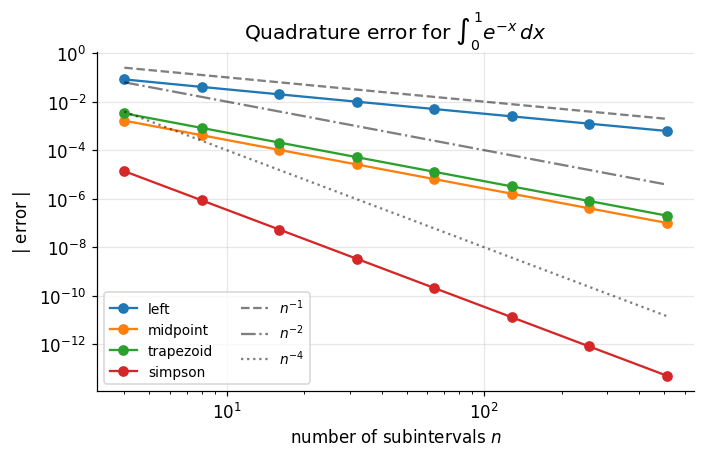

In [4]:
exact_exp = 1.0 - np.exp(-1.0)
g_exp = lambda x: np.exp(-x)


def left_rule(f, a, b, n):
    x = np.linspace(a, b, n + 1)[:-1]
    return (b - a) / n * f(x).sum()


def midpoint_rule(f, a, b, n):
    e = np.linspace(a, b, n + 1)
    return (b - a) / n * f(0.5 * (e[:-1] + e[1:])).sum()


def trapezoid_rule(f, a, b, n):
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return (b - a) / n * (0.5 * y[0] + y[1:-1].sum() + 0.5 * y[-1])


rules = {"left": (left_rule, 1), "midpoint": (midpoint_rule, 2),
         "trapezoid": (trapezoid_rule, 2), "simpson": (simpson, 4)}
ns = np.array([4, 8, 16, 32, 64, 128, 256, 512])
errors = {}

for name, (rule, predicted) in rules.items():
    err = np.array([abs(rule(g_exp, 0.0, 1.0, int(n)) - exact_exp) for n in ns])
    errors[name] = err
    observed = np.log2(err[:-1] / err[1:])
    print(f"{name:10s} predicted order {predicted},  observed orders "
          f"{np.array2string(observed, precision=2)}")
    assert abs(observed[-1] - predicted) < 0.15

fig, ax = plt.subplots()
for name, err in errors.items():
    ax.loglog(ns, err, "o-", label=name)
ax.loglog(ns, 1.0 / ns, "k--", alpha=0.5, label=r"$n^{-1}$")
ax.loglog(ns, 1.0 / ns**2.0, "k-.", alpha=0.5, label=r"$n^{-2}$")
ax.loglog(ns, 1.0 / ns**4.0, "k:", alpha=0.5, label=r"$n^{-4}$")
ax.set_xlabel("number of subintervals $n$")
ax.set_ylabel(r"$\vert$ error $\vert$")
ax.set_title(r"Quadrature error for $\int_0^1 e^{-x}\,dx$")
ax.legend(ncol=2, fontsize=9)
plt.show()

The observed orders converge to $1.00$, $2.00$, $2.00$ and $4.00$, matching the error column of the table above, and the log–log slopes lie parallel to the $n^{-1}$, $n^{-2}$ and $n^{-4}$ guides. Simpson's error at $n = 2$ is also inside the bound $\frac{(b-a)^5}{180 n^4}\max\lvert f^{(4)}\rvert = \frac{1}{2880} \approx 3.47 \times 10^{-4}$; the sweep shows how quickly that shrinks.

### 7.3 Counterexamples: what breaks when a hypothesis is dropped

Two hypotheses are tested by removal. First, Theorem 4.8 requires $g$ continuous on the **closed** interval: applying it blindly to $f(x) = x^{-2}$ on $[-1, 1]$ with $g(x) = -1/x$ returns $-2$, a negative number for a strictly positive integrand. Second, Theorem 4.2 fails for the Dirichlet function, whose Darboux gap does not shrink with $n$. The cell prints the refuting evidence for both.

In [5]:
# --- Counterexample 1: FTC II with a discontinuous "antiderivative" ---
g_bad = lambda x: -1.0 / x
ftc_blind = g_bad(1.0) - g_bad(-1.0)
print(f"FTC II applied blindly to 1/x^2 on [-1,1]: {ftc_blind:+.4f}   (integrand is > 0 everywhere!)")

# The honest computation: cut out the singularity and let the cut shrink.
for eps in (1e-1, 1e-2, 1e-3, 1e-4):
    tail = 2.0 * (1.0 / eps - 1.0)          # 2 * int_eps^1 x^-2 dx, by symmetry
    print(f"  int over |x| in [{eps:g}, 1] = {tail:12.2f}")
print("  -> diverges to +infinity; the FTC II value -2 is meaningless\n")
assert ftc_blind < 0

# --- Counterexample 2: Dirichlet function is not Darboux integrable ---
def dirichlet_gap(n):
    """U - L for the Dirichlet indicator on [0,1] under any partition into n pieces.

    Each subinterval contains both a rational and an irrational, so M_i = 1 and m_i = 0
    on every piece; the gap is sum_i 1 * dx_i = 1 no matter how fine the partition is.
    """
    widths = np.full(n, 1.0 / n)
    m_i, M_i = np.zeros(n), np.ones(n)
    return float(np.sum((M_i - m_i) * widths))


# A continuous but non-monotone f, handled by the general sampled version, for contrast.
f_osc = lambda x: np.sin(4 * np.pi * x)
for n in (10, 100, 1000, 10_000):
    L_x2, U_x2 = darboux_sums(f_sq, 0.0, 1.0, n)
    L_os, U_os = oscillation_sums(f_osc, 0.0, 1.0, n, samples=64)
    print(f"n={n:6d}   gap: x^2 -> {U_x2 - L_x2:.6f},   sin(4 pi x) -> {U_os - L_os:.6f},"
          f"   Dirichlet -> {dirichlet_gap(n):.6f}")
assert abs(dirichlet_gap(10_000) - 1.0) < 1e-12

FTC II applied blindly to 1/x^2 on [-1,1]: -2.0000   (integrand is > 0 everywhere!)
  int over |x| in [0.1, 1] =        18.00
  int over |x| in [0.01, 1] =       198.00
  int over |x| in [0.001, 1] =      1998.00
  int over |x| in [0.0001, 1] =     19998.00
  -> diverges to +infinity; the FTC II value -2 is meaningless

n=    10   gap: x^2 -> 0.100000,   sin(4 pi x) -> 0.780418,   Dirichlet -> 1.000000
n=   100   gap: x^2 -> 0.010000,   sin(4 pi x) -> 0.079921,   Dirichlet -> 1.000000
n=  1000   gap: x^2 -> 0.001000,   sin(4 pi x) -> 0.008000,   Dirichlet -> 1.000000
n= 10000   gap: x^2 -> 0.000100,   sin(4 pi x) -> 0.000800,   Dirichlet -> 1.000000


The first block shows the failure is not a rounding artefact: the honest truncated integrals grow without bound ($\approx 2/\varepsilon$), so $\int_{-1}^1 x^{-2}\,dx = +\infty$ while the illegal FTC II shortcut reports $-2$. The second block shows the Darboux gap for $x^2$ falling like $1/n$ (Theorem 4.4) and the gap for the continuous but non-monotone $\\sin(4\\pi x)$ falling too (Theorem 4.3), while the Dirichlet gap stays pinned at $1$ for every $n$ — the criterion of Theorem 4.2 is never met, so no partition makes the function integrable.

### 7.4 Hand-rolled versus library

Finally the hand-rolled `simpson` and `trapezoid_rule` are checked against `scipy.integrate.simpson`, `numpy.trapezoid` and the adaptive `scipy.integrate.quad`, on an integrand with no elementary antiderivative, $\int_0^1 e^{-x^2}\,dx = \tfrac{\sqrt{\pi}}{2}\operatorname{erf}(1)$.

In [6]:
from scipy.integrate import quad, simpson as scipy_simpson
from scipy.special import erf

f_gauss = lambda x: np.exp(-x**2)
exact_gauss = np.sqrt(np.pi) / 2 * erf(1.0)

n = 200
grid = np.linspace(0.0, 1.0, n + 1)

mine_simpson = simpson(f_gauss, 0.0, 1.0, n)
lib_simpson = scipy_simpson(f_gauss(grid), x=grid)
mine_trap = trapezoid_rule(f_gauss, 0.0, 1.0, n)
lib_trap = np.trapezoid(f_gauss(grid), grid)
adaptive, adaptive_err = quad(f_gauss, 0.0, 1.0)

print(f"exact  sqrt(pi)/2 * erf(1)   = {exact_gauss:.14f}")
print(f"mine   simpson  (n={n})      = {mine_simpson:.14f}")
print(f"scipy  simpson  (n={n})      = {lib_simpson:.14f}   |diff| = {abs(mine_simpson - lib_simpson):.2e}")
print(f"mine   trapezoid(n={n})      = {mine_trap:.14f}")
print(f"numpy  trapezoid(n={n})      = {lib_trap:.14f}   |diff| = {abs(mine_trap - lib_trap):.2e}")
print(f"scipy  quad (adaptive)      = {adaptive:.14f}   reported error = {adaptive_err:.2e}")

assert abs(mine_simpson - lib_simpson) < 1e-14
assert abs(mine_trap - lib_trap) < 1e-14
assert abs(adaptive - exact_gauss) < 1e-12

exact  sqrt(pi)/2 * erf(1)   = 0.74682413281243
mine   simpson  (n=200)      = 0.74682413281754
scipy  simpson  (n=200)      = 0.74682413281754   |diff| = 2.22e-16
mine   trapezoid(n=200)      = 0.74682259998014
numpy  trapezoid(n=200)      = 0.74682259998014   |diff| = 1.11e-16
scipy  quad (adaptive)      = 0.74682413281243   reported error = 8.29e-15


The hand-rolled rules agree with the library implementations to $10^{-14}$ — they are the same formulas, so any larger discrepancy would signal a bug in the derivation, not in the arithmetic. The adaptive `quad` matches the closed form through the error function to $10^{-12}$, confirming that a fixed-order rule and an adaptive one converge to the same number that Definition 3.4 declares to exist.

## 8. Applications

### 8.1 Physics

**Work by a variable force.** A force $F(x)$ acting along a line does work $W = \int_{x_1}^{x_2} F(x)\,dx$. For the Duffing spring $F(x) = -kx - \beta x^3$ this gives $W = -\tfrac12 k x_0^2 - \tfrac14 \beta x_0^4$, whose negative is the stored potential energy — the definite integral is what turns a force law into an energy function.

**Electrostatic potential of a continuous charge.** A rod of length $L$ with linear density $\lambda$ produces, at a point a distance $d$ beyond its end,

$$
V = \frac{1}{4\pi\varepsilon_0} \int_0^L \frac{\lambda\,dx}{(L + d) - x} = \frac{Q}{4\pi\varepsilon_0 L}\ln\!\left(1 + \frac{L}{d}\right) ,
$$

by the substitution of Theorem 4.10. Discrete superposition of point charges becomes continuous superposition by exactly the limit of Definition 3.5.

**Centre of mass.** For a body of density $\rho$ on $[a,b]$, $\bar{x} = \int_a^b x\rho(x)\,dx \big/ \int_a^b \rho(x)\,dx$: a ratio of two accumulations.

### 8.2 Probability and machine learning

**Densities and expectations.** A probability density $p$ satisfies $\int_{\mathbb{R}} p = 1$, and

$$
P(a \le X \le b) = \int_a^b p(x)\,dx, \qquad \mathbb{E}[X] = \int_{\mathbb{R}} x\,p(x)\,dx, \qquad \operatorname{Var}(X) = \int_{\mathbb{R}} (x - \mu)^2 p(x)\,dx .
$$

The normalising constant of a Gaussian energy model, $Z = \int_{\mathbb{R}} e^{-x^2/(2\sigma^2)}\,dx = \sigma\sqrt{2\pi}$, is a definite integral with no elementary antiderivative — Definition 3.4 still assigns it a value, which is the point of separating the definite integral from the indefinite one.

**Expected risk.** Supervised learning minimises

$$
R(\theta) = \mathbb{E}_{(x,y) \sim p}\big[ \ell(f_\theta(x), y) \big] = \iint \ell(f_\theta(x), y)\, p(x, y)\,dx\,dy ,
$$

and empirical risk minimisation is precisely the Riemann-sum-style approximation of this integral by a finite sample.

**Differentiating a risk under the integral.** Gradient methods need $\nabla_\theta R(\theta)$. Theorem 4.9 is what licenses moving the derivative inside the integral, $\nabla_\theta R = \int \nabla_\theta \ell\, p$, provided $\ell$ and $\nabla_\theta \ell$ are continuous — the same continuity hypothesis, now doing work in an optimiser.

**Neural ODEs and continuous normalising flows.** A hidden state obeying $\dot z = f(z(t), t; \theta)$ is transported by

$$
z(t_1) = z(t_0) + \int_{t_0}^{t_1} f(z(t), t; \theta)\,dt ,
$$

which is Theorem 4.8 read forwards; the adjoint method that supplies its gradients is Theorem 4.9 applied to the same integral. Both the forward pass and the backward pass are quadrature problems, and the rules of Section 7 are what actually run.

## 9. Key Takeaways

1. The indefinite integral (Definition 3.1) inverts differentiation; the definite integral (Definition 3.4) is a limit of rectangle sums. They are independent constructions, joined only by Theorems 4.7 and 4.8.
2. Integrability of a **bounded** $f$ on $[a,b]$ is equivalent to making $U(f,P) - L(f,P)$ arbitrarily small (Theorem 4.2); every existence proof in Section 5 is a way of driving that oscillation sum to zero.
3. **Continuity on a closed bounded interval** implies integrability (Theorem 4.3), via uniform continuity; **monotonicity** implies it too (Theorem 4.4), with gap exactly $(b-a)\lvert f(b)-f(a)\rvert/n$ on the uniform partition.
4. If $f$ is **continuous** on $[a,b]$, then $F(x) = \int_a^x f$ is differentiable with $F' = f$ (Theorem 4.7) — so every continuous function on a closed interval has an antiderivative.
5. If $f$ is **integrable** and $g$ is **continuous on $[a,b]$, differentiable on $(a,b)$** with $g' = f$, then $\int_a^b f = g(b) - g(a)$ (Theorem 4.8); dropping continuity of $g$ at an interior point produces the $\int_{-1}^{1}x^{-2} = -2$ absurdity of Section 7.3.
6. With $f$ and $\partial f/\partial x$ **continuous** on a rectangle and $u, v$ **$C^1$**, the derivative of a parametric integral has three terms, two boundary and one interior (Theorem 4.9) — the basis of Feynman's trick and of the adjoint method.
7. **Continuous differentiability of $g$** and **continuity of $f$** make substitution valid with oriented limits $g(a), g(b)$ (Theorem 4.10); monotonicity of $g$ is not required.
8. Quadrature error orders are $O(h)$ for left Riemann, $O(h^2)$ for midpoint and trapezoid, $O(h^4)$ for Simpson, and Section 7.2 measures exactly those exponents.

## 10. References

- Spivak, M. *Calculus*, 4th ed. — Ch. 13 (Darboux definition and the integrability criterion), Ch. 14 (FTC I and II, Theorems 1 and 2), Ch. 18–19 (log, exp and their integrals).
- Apostol, T. M. *Mathematical Analysis*, 2nd ed. — Theorem 7.19 (Riemann–Darboux equivalence), §7.26 Theorem 7.48 (Lebesgue's criterion).
- Apostol, T. M. *Calculus, Volume I*, 2nd ed. — Ch. 1–2 (step-function-first construction), Ch. 5 (FTC and techniques).
- Rudin, W. *Principles of Mathematical Analysis*, 3rd ed. — §6.1–6.7 (Riemann–Stieltjes integral, Theorem 6.6), Theorem 6.20 (FTC I), Theorem 6.21 (FTC II).
- Stewart, J. *Calculus: Early Transcendentals*, 8th ed. — Ch. 5 (definite integral, FTC), Ch. 7 (substitution, parts, partial fractions, trigonometric and Weierstrass substitutions).
- Demidovich, B. P. *Problems in Mathematical Analysis* — Ch. IV–V (computational integration and reduction formulas).
- Trefethen, L. N., and Bau, D. *Numerical Linear Algebra* — Lecture 12 for the conditioning language used in Section 7; Heath, M. T. *Scientific Computing*, 2nd ed., Ch. 8 for the quadrature error constants quoted in the table.
- Pólya, G., and Szegő, G. *Problems and Theorems in Analysis I* — Part I (asymptotics of integral sequences, used in the L3 exercises).